In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve,
    mean_absolute_error, mean_squared_error, r2_score
)

RANDOM_STATE = 42
os.makedirs('../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

print("Imports OK")

Imports OK


In [2]:
# Chargement des données preprocessées
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')

X_train_under     = np.load('../data/processed/X_train_under.npy')
y_train_clf_under = np.load('../data/processed/y_train_clf_under.npy')

# SMOTE
X_train_smote     = np.load('../data/processed/X_train_smote.npy')
y_train_clf_smote = np.load('../data/processed/y_train_clf_smote.npy')

# Tâche 1 — Classification
y_train_clf = np.load('../data/processed/y_train_clf.npy')
y_test_clf  = np.load('../data/processed/y_test_clf.npy')

# Tâche 2 — Régression
y_test_reg  = np.load('../data/processed/y_test_reg.npy')

# Noms des features
feature_names = pd.read_csv('../data/processed/feature_names.csv')['0'].tolist()

print(f" Données chargées")
print(f"   X_train         : {X_train.shape} (original)")
print(f"   X_train_under   : {X_train_under.shape} (rééquilibré 50/50)")
print(f"   X_test          : {X_test.shape}")
print(f"   Churners train_under : {y_train_clf_under.sum()} ({y_train_clf_under.mean()*100:.1f}%)")
print(f"   Churners test        : {y_test_clf.sum()} ({y_test_clf.mean()*100:.1f}%)")
print(f"   X_test  : {X_test.shape}")
print(f"   Churners dans test : {y_test_clf.sum()} ({y_test_clf.mean()*100:.1f}%)")

 Données chargées
   X_train         : (8000, 50) (original)
   X_train_under   : (1634, 50) (rééquilibré 50/50)
   X_test          : (2000, 50)
   Churners train_under : 817 (50.0%)
   Churners test        : 204 (10.2%)
   X_test  : (2000, 50)
   Churners dans test : 204 (10.2%)


## Tâche 1 — Classification du Churn


In [3]:
# TÂCHE 1 — CLASSIFICATION

# ---- Modèle 1 : Undersampling ----
# ============================================================
# TÂCHE 1 — CLASSIFICATION
# ============================================================

# Définition du modèle
lr_clf = LogisticRegression(
    max_iter=1000,            # Assure la convergence
    random_state=RANDOM_STATE
)

# Entraînement
# Entraînement sur les données rééquilibrées (undersampling)
lr_clf.fit(X_train_under, y_train_clf_under)

# Prédictions
y_pred_under  = lr_clf.predict(X_test)
y_proba_under = lr_clf.predict_proba(X_test)[:, 1]
y_pred_clf    = y_pred_under
y_proba_clf   = y_proba_under

print("Modèle entraîné !")
print(f"\n Résultats — Régression Logistique (Classification)")
print(f"   Accuracy  : {accuracy_score(y_test_clf, y_pred_under):.4f}")
print(f"   Precision : {precision_score(y_test_clf, y_pred_under):.4f}")
print(f"   Recall    : {recall_score(y_test_clf, y_pred_under):.4f}")
print(f"   F1-Score  : {f1_score(y_test_clf, y_pred_under):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_under):.4f}")

print()

# ---- Modèle 2 : SMOTE ----
lr_clf_smote = lr_clf.__class__(**lr_clf.get_params())
lr_clf_smote.fit(X_train_smote, y_train_clf_smote)
y_pred_smote  = lr_clf_smote.predict(X_test)
y_proba_smote = lr_clf_smote.predict_proba(X_test)[:, 1]

print(f"=== Logistic Regression — SMOTE ===")
print(f"   Accuracy  : {accuracy_score(y_test_clf, y_pred_smote):.4f}")
print(f"   Precision : {precision_score(y_test_clf, y_pred_smote):.4f}")
print(f"   Recall    : {recall_score(y_test_clf, y_pred_smote):.4f}")
print(f"   F1-Score  : {f1_score(y_test_clf, y_pred_smote):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_smote):.4f}")

# Sélection du meilleur
recall_under = recall_score(y_test_clf, y_pred_under)
recall_smote = recall_score(y_test_clf, y_pred_smote)
if recall_smote >= recall_under:
    lr_clf = lr_clf_smote
    y_pred_clf  = y_pred_smote
    y_proba_clf = y_proba_smote
    best_technique = 'SMOTE'
else:
    best_technique = 'Undersampling'
print(f"\n→ Meilleure technique : {best_technique} (Recall={max(recall_under, recall_smote):.4f})")

Modèle entraîné !

 Résultats — Régression Logistique (Classification)
   Accuracy  : 0.6540
   Precision : 0.1738
   Recall    : 0.6373
   F1-Score  : 0.2731
   ROC-AUC   : 0.7090

=== Logistic Regression — SMOTE ===
   Accuracy  : 0.6715
   Precision : 0.1823
   Recall    : 0.6373
   F1-Score  : 0.2835
   ROC-AUC   : 0.7120

→ Meilleure technique : SMOTE (Recall=0.6373)


## Analyse des métriques



## Matrice de Confusion


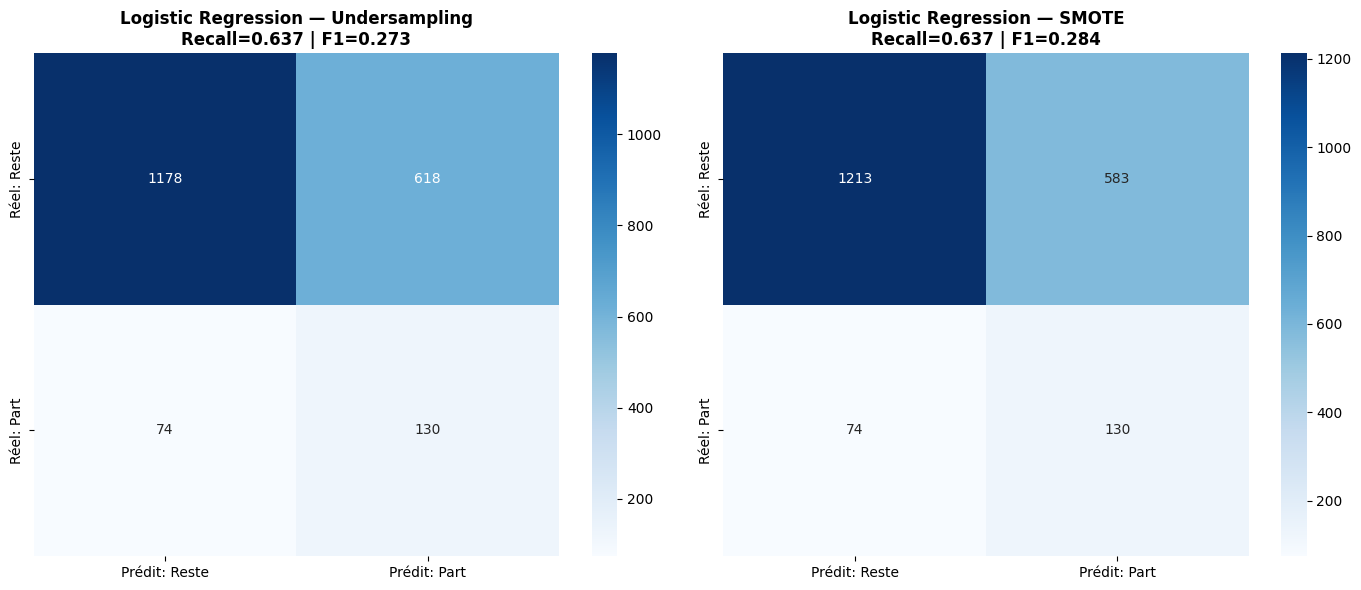


Meilleur modèle (SMOTE) :
   FN (churners manqués) : 74
   TP (churners détectés) : 130


In [4]:
# MATRICE DE CONFUSION — Comparaison

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (y_pred, title, cmap) in zip(axes, [
    (y_pred_under, 'Logistic Regression — Undersampling', 'Blues'),
    (y_pred_smote, 'Logistic Regression — SMOTE', 'Blues'),
]):
    cm_plot = confusion_matrix(y_test_clf, y_pred)
    sns.heatmap(cm_plot, annot=True, fmt='d', cmap=cmap,
                xticklabels=['Prédit: Reste', 'Prédit: Part'],
                yticklabels=['Réel: Reste', 'Réel: Part'], ax=ax)
    ax.set_title(f'{title}\nRecall={recall_score(y_test_clf, y_pred):.3f} | F1={f1_score(y_test_clf, y_pred):.3f}',
                 fontweight='bold')

plt.tight_layout()
plt.savefig('../results/lr_confusion_matrix.png', dpi=150)
plt.show()

cm = confusion_matrix(y_test_clf, y_pred_clf)
tn, fp, fn, tp = cm.ravel()
print(f"\nMeilleur modèle ({best_technique}) :")
print(f"   FN (churners manqués) : {fn}")
print(f"   TP (churners détectés) : {tp}")

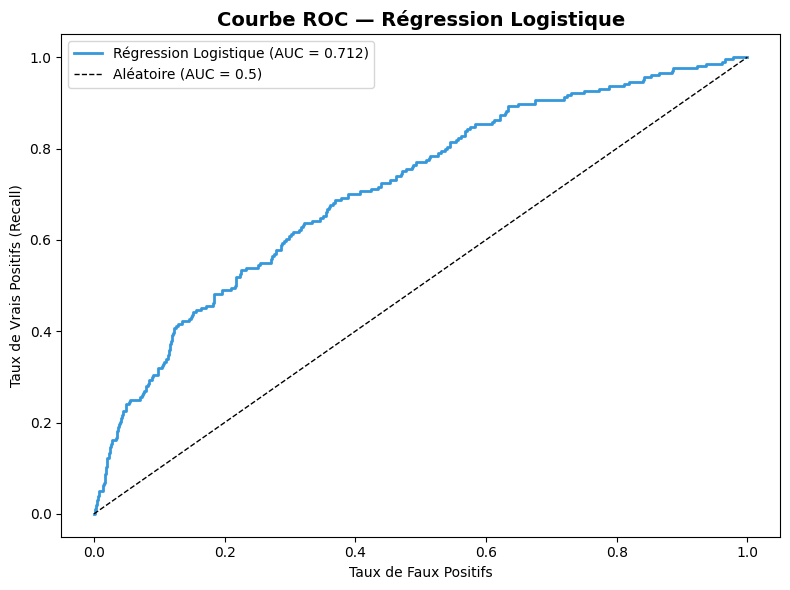

In [5]:
# COURBE ROC

fpr, tpr, _ = roc_curve(y_test_clf, y_proba_clf)
auc = roc_auc_score(y_test_clf, y_proba_clf)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#3498db', linewidth=2,
         label=f'Régression Logistique (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aléatoire (AUC = 0.5)')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs (Recall)')
plt.title('Courbe ROC — Régression Logistique', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../results/lr_roc_curve.png', dpi=150)
plt.show()

## Tâche 2 — Régression du Revenu à Risque


In [6]:
# ============================================================
# TÂCHE 2 — RÉGRESSION (Ridge baseline)
# ============================================================

# Charger les données spécifiques régression
X_train_reg     = np.load('../data/processed/X_train_reg.npy')       # churners uniquement
y_train_reg_log = np.load('../data/processed/y_train_reg_log.npy')   # log-transformé
y_test_reg      = np.load('../data/processed/y_test_reg.npy')        # valeurs réelles €

lr_reg = Ridge(alpha=1.0, random_state=RANDOM_STATE)

# Entraînement sur churners uniquement avec y log-transformé
lr_reg.fit(X_train_reg, y_train_reg_log)

# Prédiction sur TOUS les clients du test
y_pred_reg_log = lr_reg.predict(X_test)

# Transformation inverse log → euros réels
y_pred_reg = np.expm1(y_pred_reg_log)
y_pred_reg = np.maximum(y_pred_reg, 0)  # pas de valeurs négatives

# Évaluation sur les churners du test uniquement
churners_test_mask = y_test_reg > 0
mae  = mean_absolute_error(y_test_reg[churners_test_mask], y_pred_reg[churners_test_mask])
rmse = np.sqrt(mean_squared_error(y_test_reg[churners_test_mask], y_pred_reg[churners_test_mask]))
r2   = r2_score(y_test_reg[churners_test_mask], y_pred_reg[churners_test_mask])

print("Modèle de régression entraîné !")
print(f"\nRésultats — Ridge Regression (churners uniquement)")
print(f"   MAE  : {mae:.2f} €")
print(f"   RMSE : {rmse:.2f} €")
print(f"   R²   : {r2:.4f}")

Modèle de régression entraîné !

Résultats — Ridge Regression (churners uniquement)
   MAE  : 330.91 €
   RMSE : 724.96 €
   R²   : 0.4183


In [7]:
# SAUVEGARDE DES MODÈLES ET RÉSULTATS

# Sauvegarde des modèles
print(f'Sauvegarde du meilleur modèle : {best_technique}')
joblib.dump(lr_clf, '../models/lr_classification.pkl')
joblib.dump(lr_reg, '../models/lr_regression.pkl')

# Sauvegarde des résultats pour la comparaison finale
results_clf = {
    'model': 'Logistic Regression (' + best_technique + ')',
    'accuracy':  accuracy_score(y_test_clf, y_pred_clf),
    'precision': precision_score(y_test_clf, y_pred_clf),
    'recall':    recall_score(y_test_clf, y_pred_clf),
    'f1':        f1_score(y_test_clf, y_pred_clf),
    'roc_auc':   roc_auc_score(y_test_clf, y_proba_clf)
}

results_reg = {
    'model': 'Ridge Regression',
    'mae':  mae,
    'rmse': rmse,
    'r2':   r2
}

pd.DataFrame([results_clf]).to_csv('../results/lr_clf_results.csv', index=False)
pd.DataFrame([results_reg]).to_csv('../results/lr_reg_results.csv', index=False)

print("Modèles sauvegardés dans ../models/")
print("Résultats sauvegardés dans ../results/")
print(f"\nRésumé Classification :")
for k, v in results_clf.items():
    if k != 'model':
        print(f"   {k:10} : {v:.4f}")

Sauvegarde du meilleur modèle : SMOTE
Modèles sauvegardés dans ../models/
Résultats sauvegardés dans ../results/

Résumé Classification :
   accuracy   : 0.6715
   precision  : 0.1823
   recall     : 0.6373
   f1         : 0.2835
   roc_auc    : 0.7120


## Synthèse — Régression Logistique (Baseline)
